# Assumption Junction: Telco Customer Churn

This notebook builds and compares three interpretable models for customer churn:

1. Linear regression, treating churn as a continuous 0/1 outcome.
2. Logistic regression, treating churn as a binary classification problem.
3. A generalized additive model (GAM), allowing smooth non-linear effects for numeric features.

The goal is not only prediction. The main goal is to check whether each model's assumptions are reasonable, interpret what the model says about churn risk, and recommend a responsible model for a telecommunications company.

Dataset source: Kaggle Telco Customer Churn dataset (`blastchar/telco-customer-churn`).


## Introduction

Customer churn means that a customer leaves the company. For a telecom company, churn prediction can support retention work, such as identifying customers who may need better service, pricing, or contract options.

The target variable is `Churn`, encoded as:

- `0`: customer did not churn
- `1`: customer churned

This notebook uses interpretable models because the business needs to understand the factors associated with churn, not just make predictions.


## Load & Clean Data

The primary dataset source is Kaggle: `blastchar/telco-customer-churn`. The notebook uses `kagglehub` to download the Kaggle dataset directly. A local CSV fallback is also included so the notebook can still run if the dataset has already been downloaded into a `data/` folder.


In [77]:
# Install Kaggle dataset helper if the notebook is running in a fresh Colab environment.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('kagglehub') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])

In [78]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import scipy.integrate as scipy_integrate
if not hasattr(scipy_integrate, 'simps') and hasattr(scipy_integrate, 'simpson'):
    # Compatibility patch for older statsmodels GAM code running on newer SciPy versions.
    scipy_integrate.simps = scipy_integrate.simpson

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.gam.api import GLMGam, BSplines
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)


In [79]:
kaggle_dataset = 'blastchar/telco-customer-churn'
kaggle_csv_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

local_candidates = [
    Path('data') / kaggle_csv_name,
    Path('data') / 'Telco-Customer-Churn.csv',
]

if any(path.exists() for path in local_candidates):
    data_path = next(path for path in local_candidates if path.exists())
else:
    import kagglehub

    kaggle_dir = Path(kagglehub.dataset_download(kaggle_dataset))
    matches = list(kaggle_dir.rglob(kaggle_csv_name))
    if not matches:
        matches = list(kaggle_dir.rglob('*.csv'))
    if not matches:
        raise FileNotFoundError('No CSV file was found in the downloaded Kaggle dataset.')
    data_path = matches[0]

df_raw = pd.read_csv(data_path)
print(f'Loaded data from: {data_path}')
print('Dataset source: Kaggle - https://www.kaggle.com/datasets/blastchar/telco-customer-churn')
df_raw.head()


100%|██████████| 172k/172k [00:00<00:00, 5.41MB/s]

Extracting model files...
Loaded data from: /Users/sungtsewu/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset source: Kaggle - https://www.kaggle.com/datasets/blastchar/telco-customer-churn


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [80]:
df = df_raw.copy()

# TotalCharges contains blank strings for a small number of customers.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Make SeniorCitizen easier to interpret as a category.
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Encode target for modeling.
df['ChurnBinary'] = df['Churn'].map({'No': 0, 'Yes': 1})

missing_before = df.isna().sum().sort_values(ascending=False)
print('Missing values before cleaning:')
display(missing_before[missing_before > 0])

# Drop the 11 rows with missing TotalCharges.
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

print(f'Cleaned shape: {df.shape}')
print(f'Churn rate: {df["ChurnBinary"].mean():.3f}')
df.head()


Missing values before cleaning:


TotalCharges    11
dtype: int64

Cleaned shape: (7032, 22)
Churn rate: 0.266


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnBinary
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [81]:
target = 'ChurnBinary'
id_col = 'customerID'
original_target = 'Churn'

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [
    col for col in df.columns
    if col not in numeric_features + [target, id_col, original_target]
]

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])


Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train size: 5274
Test size: 1758


In [82]:
def make_onehot_encoder():
    """Support both newer and older scikit-learn versions."""
    try:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', make_onehot_encoder(), categorical_features),
    ],
    remainder='drop',
)

preprocessor.fit(X_train)

feature_names = list(preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features))
feature_names += list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

X_train_processed = pd.DataFrame(
    preprocessor.transform(X_train),
    columns=feature_names,
    index=X_train.index,
)
X_test_processed = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=feature_names,
    index=X_test.index,
)

print(f'Number of model features after one-hot encoding: {len(feature_names)}')
X_train_processed.head()


Number of model features after one-hot encoding: 30


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3681,-0.550434,1.162877,-0.179659,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
5544,-1.283779,-0.305269,-0.984606,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
6859,0.671808,0.321096,0.624738,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1869,0.427360,0.713817,0.560688,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
147,-1.283779,-0.638336,-0.989019,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Exploratory Data Analysis

This section checks the data before modeling. The most important early questions are:

- Is churn balanced or imbalanced?
- Do numeric features show approximately linear relationships with churn?
- Are categorical features visibly related to churn?
- Are numeric predictors strongly correlated with each other?


In [83]:
summary = pd.DataFrame({
    'rows': [df.shape[0]],
    'columns': [df.shape[1]],
    'churn_rate': [df[target].mean()],
    'non_churn_rate': [1 - df[target].mean()],
})
summary


,rows,columns,churn_rate,non_churn_rate
0,7032,22,0.265785,0.734215


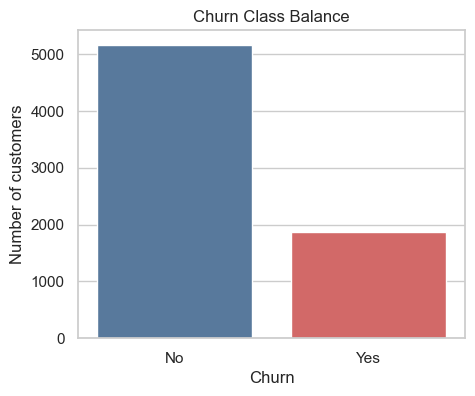

In [84]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Churn', order=['No', 'Yes'], palette=['#4C78A8', '#E45756'], ax=ax)
ax.set_title('Churn Class Balance')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of customers')
plt.show()


,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


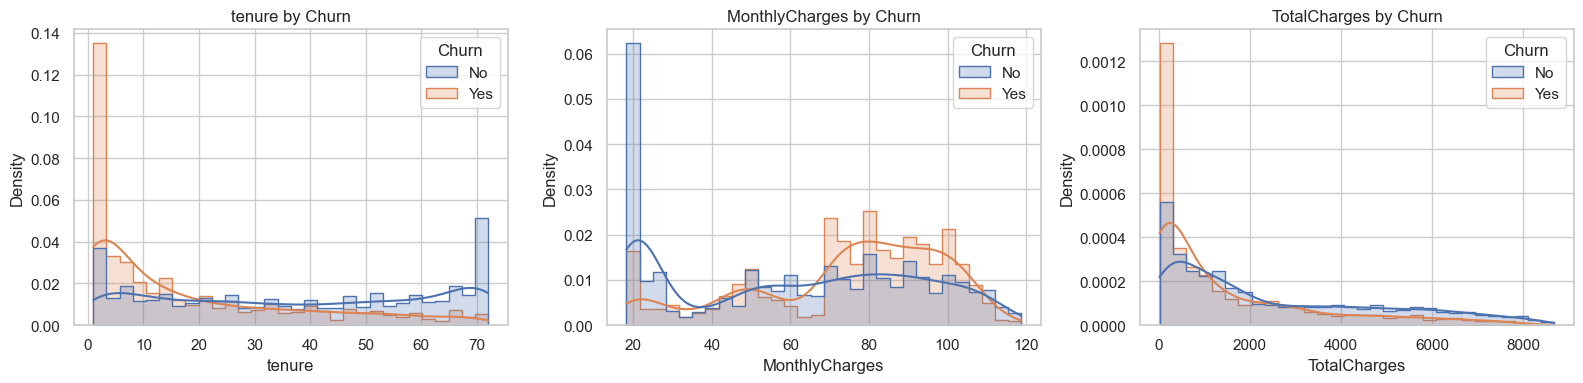

In [85]:
display(df[numeric_features].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True, element='step', stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()


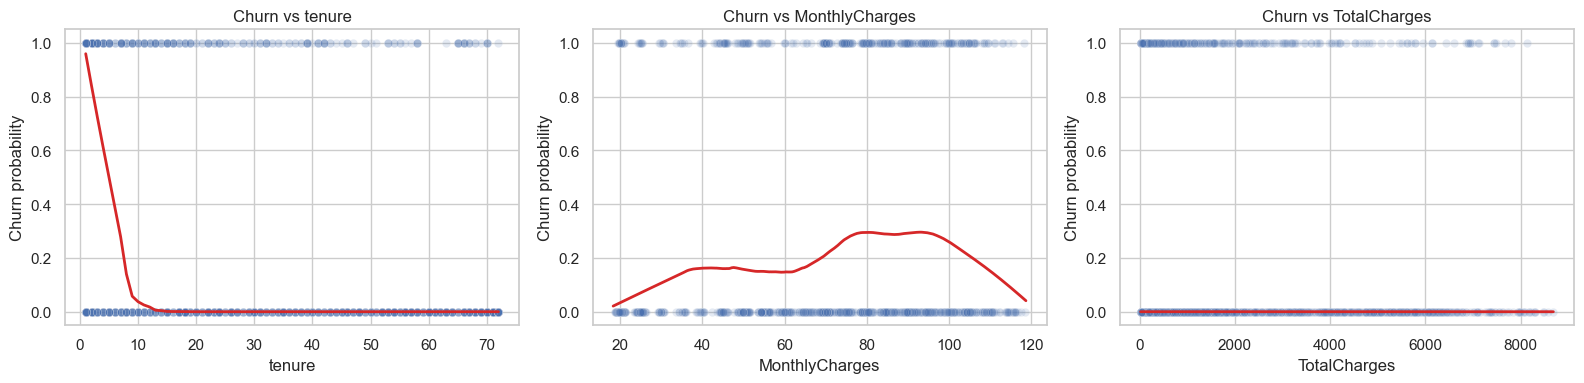

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    # LOWESS shows whether the average churn pattern is close to linear.
    smooth = lowess(df[target], df[col], frac=0.35, return_sorted=True)
    sns.scatterplot(data=df.sample(1200, random_state=RANDOM_STATE), x=col, y=target, alpha=0.15, ax=ax)
    ax.plot(smooth[:, 0], smooth[:, 1], color='#D62728', linewidth=2)
    ax.set_title(f'Churn vs {col}')
    ax.set_ylabel('Churn probability')
plt.tight_layout()
plt.show()


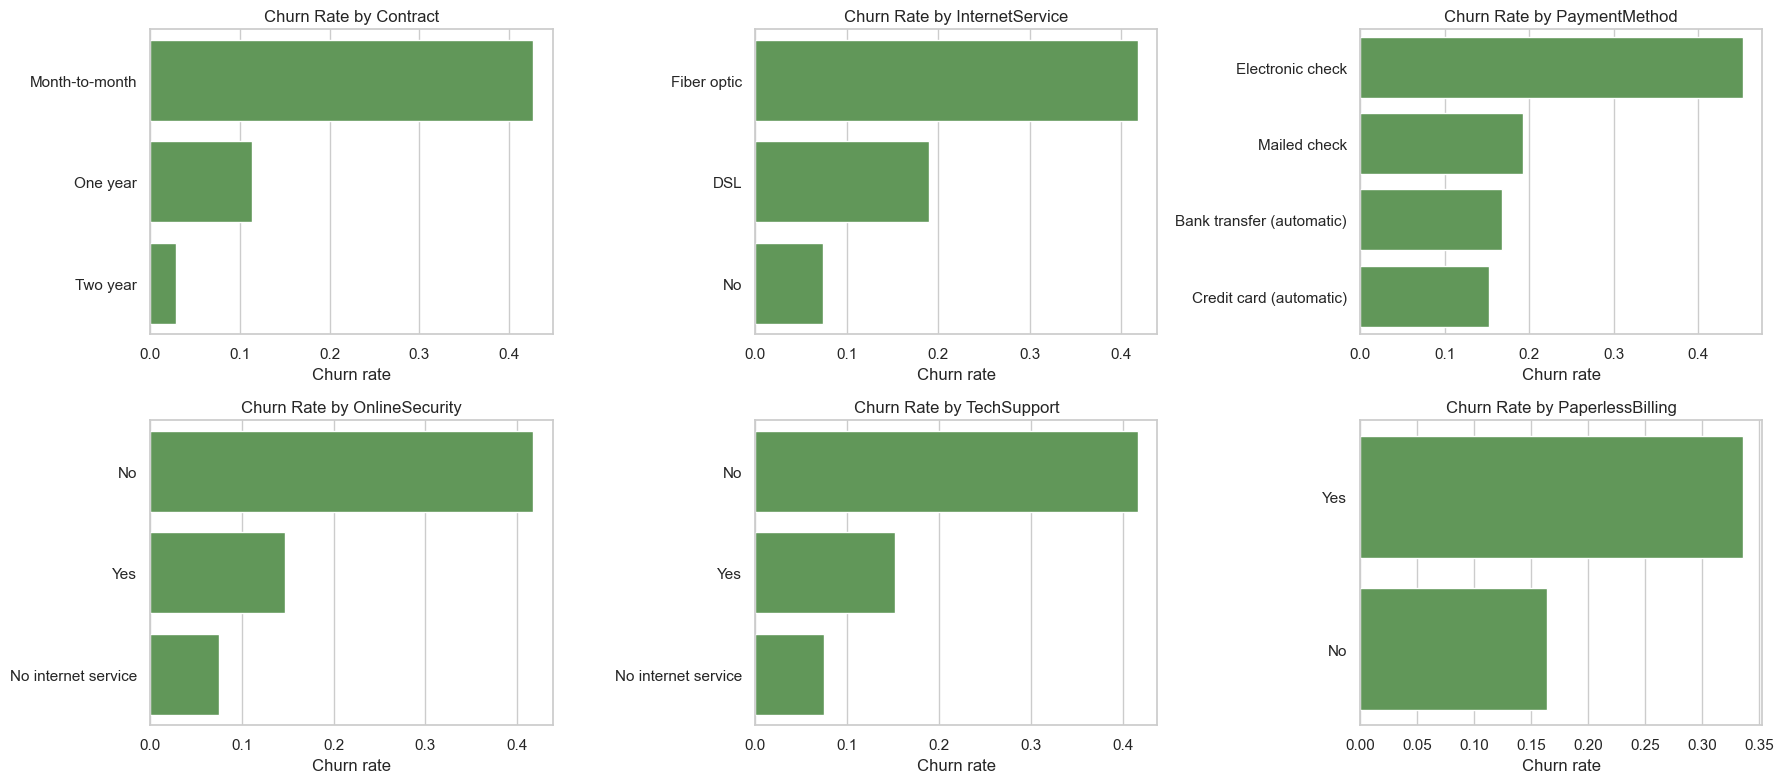

In [87]:
important_categoricals = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, important_categoricals):
    churn_by_group = df.groupby(col)[target].mean().sort_values(ascending=False)
    sns.barplot(x=churn_by_group.values, y=churn_by_group.index, ax=ax, color='#59A14F')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn rate')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()


,tenure,MonthlyCharges,TotalCharges,ChurnBinary
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
ChurnBinary,-0.354049,0.192858,-0.199484,1.000000


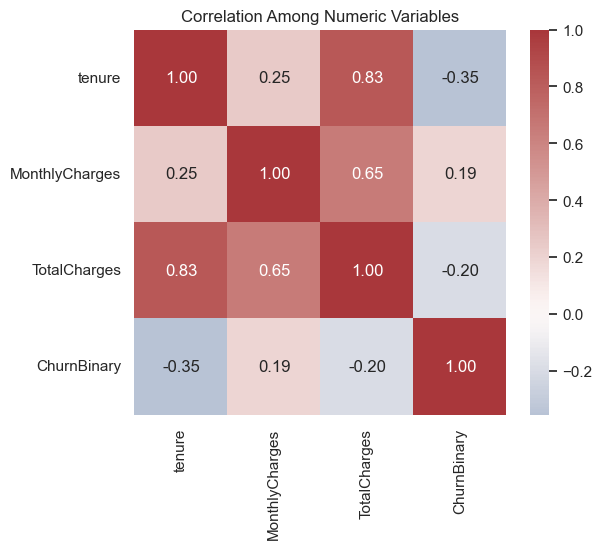

In [88]:
correlation = df[numeric_features + [target]].corr()

display(correlation)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='vlag', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Among Numeric Variables')
plt.show()


## Assumption Checks

Different models make different assumptions. Some assumptions can be checked directly with plots or diagnostics. Others, such as independent observations, depend on how the data was collected and cannot be fully verified from this CSV alone.


In [89]:
def compute_vif(design_matrix):
    vif_rows = []
    for i, col in enumerate(design_matrix.columns):
        if col == 'const':
            continue
        vif_rows.append({
            'feature': col,
            'VIF': variance_inflation_factor(design_matrix.values, i),
        })
    return pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

X_train_sm = sm.add_constant(X_train_processed, has_constant='add')
vif_table = compute_vif(X_train_sm)
vif_table.head(15)


,feature,VIF
8,MultipleLines_No phone service,inf
7,PhoneService_Yes,inf
16,DeviceProtection_No internet service,1.366317e+09
20,StreamingTV_No internet service,1.317363e+09
22,StreamingMovies_No internet service,5.791501e+08
14,OnlineBackup_No internet service,1.816948e+08
18,TechSupport_No internet service,1.184872e+08
11,InternetService_No,3.422461e+07
12,OnlineSecurity_No internet service,3.422461e+07
1,MonthlyCharges,8.705914e+02


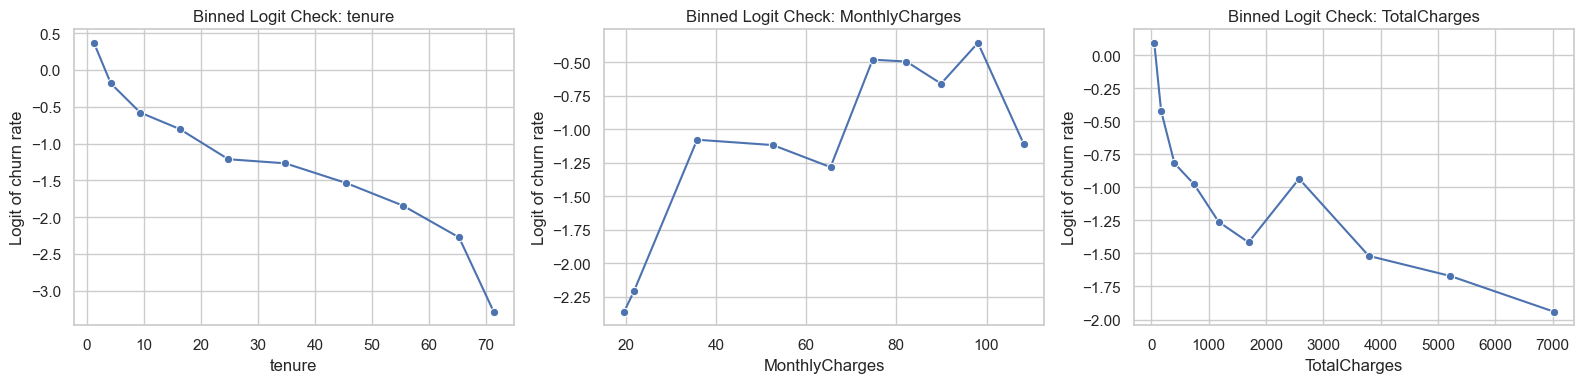

In [90]:
def plot_binned_logit(data, feature, bins=10):
    temp = data[[feature, target]].copy()
    temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
    grouped = temp.groupby('bin').agg(
        feature_mean=(feature, 'mean'),
        churn_sum=(target, 'sum'),
        n=(target, 'size'),
    )
    grouped['p'] = (grouped['churn_sum'] + 0.5) / (grouped['n'] + 1)
    grouped['logit'] = np.log(grouped['p'] / (1 - grouped['p']))
    return grouped

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    grouped = plot_binned_logit(df, col)
    sns.lineplot(data=grouped, x='feature_mean', y='logit', marker='o', ax=ax)
    ax.set_title(f'Binned Logit Check: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Logit of churn rate')
plt.tight_layout()
plt.show()


In [91]:
assumption_check_summary = pd.DataFrame([
    {
        'Model': 'Linear regression',
        'Key assumptions checked': 'Linearity, residual patterns, multicollinearity, constant variance, normal residuals',
        'Evidence': 'LOWESS plots, residual diagnostics, Breusch-Pagan test, QQ plot, VIF table',
        'Concern': 'Churn is binary, so residuals are not truly normal and variance is not constant. Predictions can fall outside 0 to 1.',
    },
    {
        'Model': 'Logistic regression',
        'Key assumptions checked': 'Binary target, linearity in the logit for numeric features, multicollinearity, calibration',
        'Evidence': 'Target encoding, binned-logit plots, VIF table, calibration/performance metrics',
        'Concern': 'Some numeric effects appear curved, especially tenure, so a strictly linear logit may miss non-linear churn patterns.',
    },
    {
        'Model': 'GAM',
        'Key assumptions checked': 'Binary target, additive structure, smooth numeric effects, calibration',
        'Evidence': 'Spline terms for numeric features, partial dependence plots, residual-style calibration checks',
        'Concern': 'GAM is still additive. It does not automatically capture interactions such as contract type combined with tenure.',
    },
])

assumption_check_summary


,Model,Key assumptions checked,Evidence,Concern
0,Linear regression,"Linearity, residual patterns, multicollinearit...","LOWESS plots, residual diagnostics, Breusch-Pa...","Churn is binary, so residuals are not truly no..."
1,Logistic regression,"Binary target, linearity in the logit for nume...","Target encoding, binned-logit plots, VIF table...","Some numeric effects appear curved, especially..."
2,GAM,"Binary target, additive structure, smooth nume...","Spline terms for numeric features, partial dep...",GAM is still additive. It does not automatical...


## Linear Regression

### Build model

Here, churn is treated as a continuous value. This is called a linear probability model. It is easy to interpret, but it is not ideal for binary outcomes.


In [92]:
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

linear_pred_train = linear_model.predict(X_train_processed)
linear_pred_test = linear_model.predict(X_test_processed)
linear_prob_test = np.clip(linear_pred_test, 0, 1)
linear_class_test = (linear_prob_test >= 0.5).astype(int)

linear_sm = sm.OLS(y_train, X_train_sm).fit()
print(linear_sm.summary().tables[0])


                            OLS Regression Results                            
Dep. Variable:            ChurnBinary   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     92.57
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:26:04   Log-Likelihood:                -2277.2
No. Observations:                5274   AIC:                             4602.
Df Residuals:                    5250   BIC:                             4760.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         


### Check assumptions

The residual diagnostics below show why linear regression is imperfect for churn. Because the target is binary, residuals usually form bands instead of a normal cloud, and error variance changes across fitted values.


Breusch-Pagan test for heteroskedasticity:


,value
LM statistic,1.016097e+03
LM p-value,2.050283e-194
F statistic,5.447166e+01
F p-value,2.260239e-223


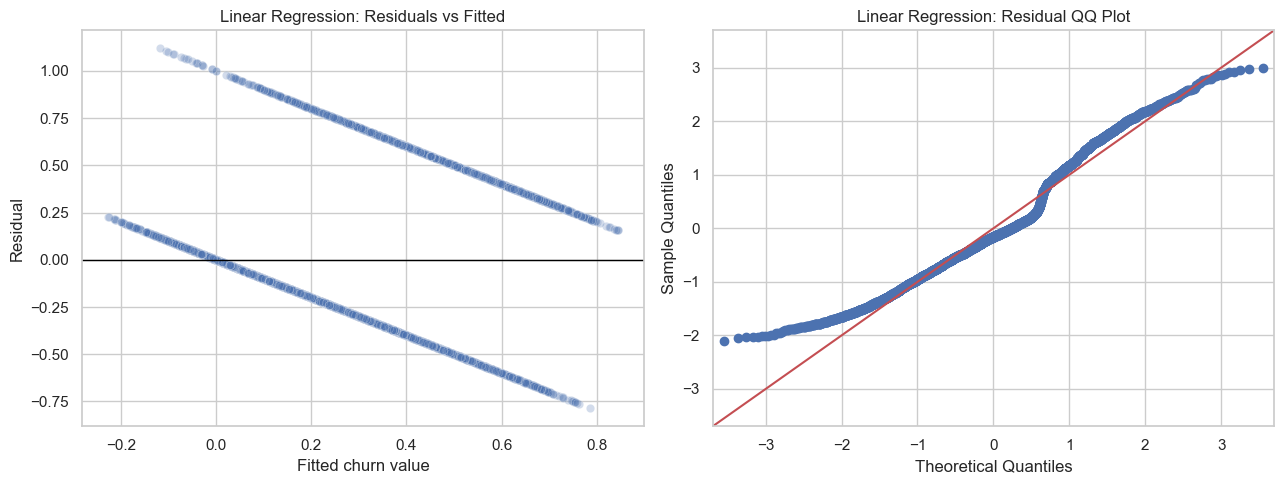

In [93]:
linear_residuals = y_train - linear_model.predict(X_train_processed)
linear_fitted = linear_model.predict(X_train_processed)

bp_test = sms.het_breuschpagan(linear_residuals, X_train_sm)
bp_results = pd.Series(
    bp_test,
    index=['LM statistic', 'LM p-value', 'F statistic', 'F p-value']
)
print('Breusch-Pagan test for heteroskedasticity:')
display(bp_results.to_frame('value'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=linear_fitted, y=linear_residuals, alpha=0.25, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Linear Regression: Residuals vs Fitted')
axes[0].set_xlabel('Fitted churn value')
axes[0].set_ylabel('Residual')

qqplot(linear_residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Linear Regression: Residual QQ Plot')
plt.tight_layout()
plt.show()


### Performance


In [94]:
def regression_metrics(y_true, predictions, probabilities=None, classes=None):
    result = {
        'RMSE': np.sqrt(mean_squared_error(y_true, predictions)),
        'MAE': mean_absolute_error(y_true, predictions),
        'R2': r2_score(y_true, predictions),
    }
    if probabilities is not None:
        result['Brier'] = brier_score_loss(y_true, probabilities)
        result['ROC_AUC'] = roc_auc_score(y_true, probabilities)
    if classes is not None:
        result['Accuracy'] = accuracy_score(y_true, classes)
        result['Precision'] = precision_score(y_true, classes)
        result['Recall'] = recall_score(y_true, classes)
        result['F1'] = f1_score(y_true, classes)
    return pd.Series(result)

linear_performance = regression_metrics(
    y_test,
    linear_pred_test,
    probabilities=linear_prob_test,
    classes=linear_class_test,
)
linear_performance.to_frame('Linear Regression')


,Linear Regression
RMSE,0.378407
MAE,0.300344
R2,0.265971
Brier,0.141700
ROC_AUC,0.832347
Accuracy,0.799772
Precision,0.648579
Recall,0.537473
F1,0.587822


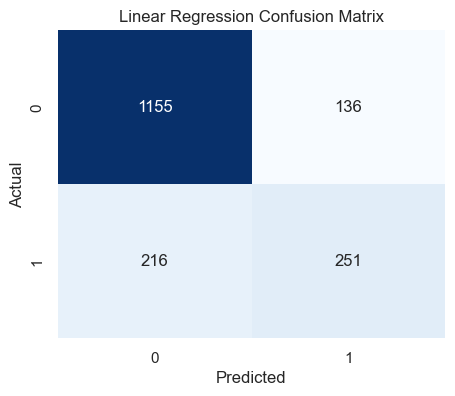

In [95]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, linear_class_test), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Linear Regression Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()


### Interpretation

For standardized numeric features, a coefficient is the expected change in churn probability for a one-standard-deviation increase in that feature, holding other features constant. For categorical dummy variables, a coefficient is the difference from the omitted reference category.


In [96]:
linear_coef = pd.DataFrame({
    'feature': feature_names,
    'coefficient': linear_model.coef_,
}).sort_values('coefficient', ascending=False)

print('Features associated with higher predicted churn:')
display(linear_coef.head(10))

print('Features associated with lower predicted churn:')
display(linear_coef.tail(10).sort_values('coefficient'))


Features associated with higher predicted churn:


,feature,coefficient
10,InternetService_Fiber optic,0.356719
21,StreamingTV_Yes,0.126501
23,StreamingMovies_Yes,0.123809
9,MultipleLines_Yes,0.091917
28,PaymentMethod_Electronic check,0.069918
7,PhoneService_Yes,0.053623
26,PaperlessBilling_Yes,0.043963
4,SeniorCitizen_Yes,0.043468
17,DeviceProtection_Yes,0.037951
29,PaymentMethod_Mailed check,0.011089


Features associated with lower predicted churn:


,feature,coefficient
1,MonthlyCharges,-0.212704
24,Contract_One year,-0.107151
2,TotalCharges,-0.101552
25,Contract_Two year,-0.076020
8,MultipleLines_No phone service,-0.053623
16,DeviceProtection_No internet service,-0.047367
22,StreamingMovies_No internet service,-0.047367
18,TechSupport_No internet service,-0.047367
20,StreamingTV_No internet service,-0.047367
12,OnlineSecurity_No internet service,-0.047367


In [97]:
linear_interpretation = """
Linear regression is very transparent: each coefficient is a direct additive change in predicted churn.
However, because churn is binary, the model violates important assumptions. It can predict values below 0 or above 1,
and its residuals are not normally distributed. I would treat it as a simple baseline, not the main production model.
"""
print(linear_interpretation)



Linear regression is very transparent: each coefficient is a direct additive change in predicted churn.
However, because churn is binary, the model violates important assumptions. It can predict values below 0 or above 1,
and its residuals are not normally distributed. I would treat it as a simple baseline, not the main production model.



## Logistic Regression

### Build model

Logistic regression is a better match for churn because it models the probability of a binary event.


In [98]:
logistic_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
logistic_model.fit(X_train_processed, y_train)

logistic_prob_test = logistic_model.predict_proba(X_test_processed)[:, 1]
logistic_class_test = (logistic_prob_test >= 0.5).astype(int)

logistic_glm = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial()).fit()
print(logistic_glm.summary().tables[0])


                 Generalized Linear Model Regression Results                  
Dep. Variable:            ChurnBinary   No. Observations:                 5274
Model:                            GLM   Df Residuals:                     5250
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2171.1
Date:                Tue, 01 Sep 2026   Deviance:                       4342.2
Time:                        19:26:08   Pearson chi2:                 6.06e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.2845
Covariance Type:            nonrobust                                         


### Check assumptions

The main diagnostic question is whether numeric predictors have an approximately linear relationship with the log-odds of churn. The binned-logit plots above are used for that check. Calibration is also useful because logistic regression outputs probabilities.


In [99]:
logistic_assumption_notes = pd.DataFrame([
    {'Assumption': 'Binary outcome', 'Check': 'Churn is encoded as 0/1', 'Status': 'Met'},
    {'Assumption': 'Independent observations', 'Check': 'Each row is one customer; collection process is not fully known', 'Status': 'Reasonable but not fully testable'},
    {'Assumption': 'Linearity in the logit', 'Check': 'Binned-logit plots for tenure, MonthlyCharges, and TotalCharges', 'Status': 'Partly met; tenure appears non-linear'},
    {'Assumption': 'Limited multicollinearity', 'Check': 'VIF table from encoded features', 'Status': 'Some concern if VIF values are high'},
    {'Assumption': 'Probability calibration', 'Check': 'Brier score and probability bins below', 'Status': 'Checked empirically'},
])
logistic_assumption_notes


,Assumption,Check,Status
0,Binary outcome,Churn is encoded as 0/1,Met
1,Independent observations,Each row is one customer; collection process i...,Reasonable but not fully testable
2,Linearity in the logit,"Binned-logit plots for tenure, MonthlyCharges,...",Partly met; tenure appears non-linear
3,Limited multicollinearity,VIF table from encoded features,Some concern if VIF values are high
4,Probability calibration,Brier score and probability bins below,Checked empirically


,mean_predicted_probability,observed_churn_rate,n
0,0.015322,0.005682,176
1,0.049321,0.022727,176
2,0.109531,0.051136,176
3,0.217366,0.114286,175
4,0.352290,0.187500,176
5,0.466619,0.210227,176
6,0.600569,0.262857,175
7,0.715892,0.471591,176
8,0.802728,0.607955,176
9,0.874733,0.721591,176


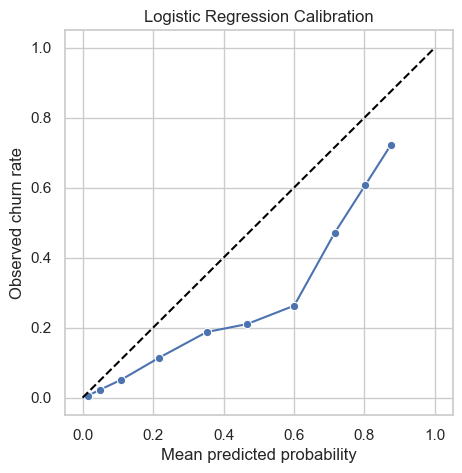

In [100]:
def calibration_table(y_true, probabilities, bins=10):
    temp = pd.DataFrame({'y_true': y_true, 'probability': probabilities})
    temp['bin'] = pd.qcut(temp['probability'], q=bins, duplicates='drop')
    return temp.groupby('bin').agg(
        mean_predicted_probability=('probability', 'mean'),
        observed_churn_rate=('y_true', 'mean'),
        n=('y_true', 'size'),
    ).reset_index(drop=True)

logistic_calibration = calibration_table(y_test, logistic_prob_test)
display(logistic_calibration)

fig, ax = plt.subplots(figsize=(5, 5))
sns.lineplot(data=logistic_calibration, x='mean_predicted_probability', y='observed_churn_rate', marker='o', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='black')
ax.set_title('Logistic Regression Calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed churn rate')
plt.show()


### Performance


In [101]:
def classification_metrics(y_true, probabilities, classes):
    return pd.Series({
        'ROC_AUC': roc_auc_score(y_true, probabilities),
        'Brier': brier_score_loss(y_true, probabilities),
        'Accuracy': accuracy_score(y_true, classes),
        'Precision': precision_score(y_true, classes),
        'Recall': recall_score(y_true, classes),
        'F1': f1_score(y_true, classes),
    })

logistic_performance = classification_metrics(y_test, logistic_prob_test, logistic_class_test)
logistic_performance.to_frame('Logistic Regression')


,Logistic Regression
ROC_AUC,0.840090
Brier,0.171195
Accuracy,0.733220
Precision,0.498660
Recall,0.796574
F1,0.613355


              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1291
       Churn       0.50      0.80      0.61       467

    accuracy                           0.73      1758
   macro avg       0.70      0.75      0.70      1758
weighted avg       0.80      0.73      0.75      1758



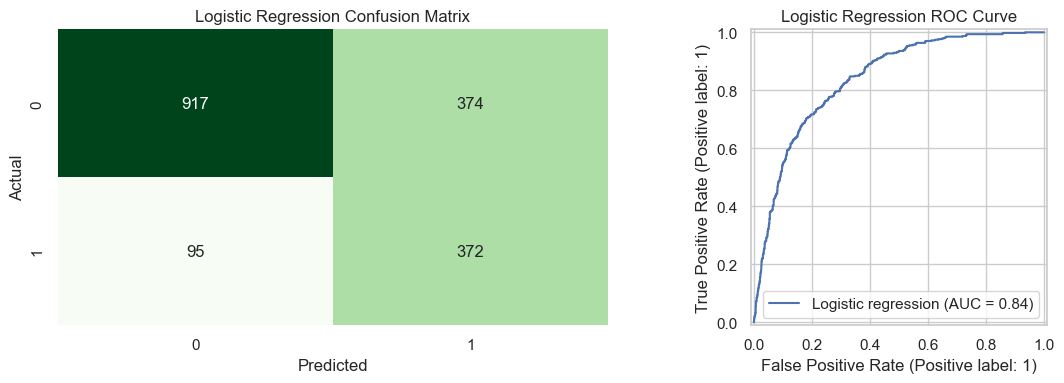

In [102]:
print(classification_report(y_test, logistic_class_test, target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, logistic_class_test), annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, logistic_prob_test, ax=axes[1], name='Logistic regression')
axes[1].set_title('Logistic Regression ROC Curve')
plt.tight_layout()
plt.show()


### Interpretation

Logistic coefficients are easiest to explain as odds ratios. An odds ratio above 1 means the feature is associated with higher churn odds. An odds ratio below 1 means the feature is associated with lower churn odds.


In [103]:
logistic_coef = pd.DataFrame({
    'feature': feature_names,
    'coefficient_log_odds': logistic_model.coef_[0],
})
logistic_coef['odds_ratio'] = np.exp(logistic_coef['coefficient_log_odds'])
logistic_coef = logistic_coef.sort_values('odds_ratio', ascending=False)

print('Features associated with higher churn odds:')
display(logistic_coef.head(10))

print('Features associated with lower churn odds:')
display(logistic_coef.tail(10).sort_values('odds_ratio'))


Features associated with higher churn odds:


,feature,coefficient_log_odds,odds_ratio
10,InternetService_Fiber optic,1.200439,3.321574
2,TotalCharges,0.607081,1.835068
21,StreamingTV_Yes,0.413756,1.512488
23,StreamingMovies_Yes,0.389913,1.476852
28,PaymentMethod_Electronic check,0.379165,1.461064
9,MultipleLines_Yes,0.338038,1.402194
26,PaperlessBilling_Yes,0.293206,1.340718
4,SeniorCitizen_Yes,0.198202,1.219209
29,PaymentMethod_Mailed check,0.079734,1.082999
17,DeviceProtection_Yes,0.059725,1.061545


Features associated with lower churn odds:


,feature,coefficient_log_odds,odds_ratio
25,Contract_Two year,-1.411861,0.243689
0,tenure,-1.250652,0.286318
24,Contract_One year,-0.713853,0.489754
1,MonthlyCharges,-0.540088,0.582697
7,PhoneService_Yes,-0.372617,0.688929
13,OnlineSecurity_Yes,-0.350976,0.704001
19,TechSupport_Yes,-0.344750,0.708398
6,Dependents_Yes,-0.252707,0.776696
12,OnlineSecurity_No internet service,-0.184826,0.831249
11,InternetService_No,-0.184826,0.831249


In [104]:
logistic_interpretation = """
Logistic regression is a strong interpretable choice for this task because the target is binary and predictions are probabilities.
The largest positive odds ratios identify customer profiles associated with higher churn risk, while odds ratios below 1 identify retention-associated features.
The main limitation is that the model assumes each numeric feature has a straight-line effect on the log-odds scale.
"""
print(logistic_interpretation)



Logistic regression is a strong interpretable choice for this task because the target is binary and predictions are probabilities.
The largest positive odds ratios identify customer profiles associated with higher churn risk, while odds ratios below 1 identify retention-associated features.
The main limitation is that the model assumes each numeric feature has a straight-line effect on the log-odds scale.



## GAM

### Build model

A GAM keeps the model interpretable while allowing non-linear smooth curves for numeric features. This is useful here because EDA suggests churn may not change linearly with tenure and charges.

In this implementation:

- `tenure`, `MonthlyCharges`, and `TotalCharges` are modeled with spline terms.
- One-hot encoded categorical features are included as linear terms.
- The response uses a binomial family because churn is binary.


In [105]:
# Smooth terms for numeric features only.
num_scaler_for_gam = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    num_scaler_for_gam.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)
X_test_num_scaled = pd.DataFrame(
    num_scaler_for_gam.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)

# Linear terms for categorical features.
cat_encoder_for_gam = make_onehot_encoder()
X_train_cat = pd.DataFrame(
    cat_encoder_for_gam.fit_transform(X_train[categorical_features]),
    columns=cat_encoder_for_gam.get_feature_names_out(categorical_features),
    index=X_train.index,
)
X_test_cat = pd.DataFrame(
    cat_encoder_for_gam.transform(X_test[categorical_features]),
    columns=cat_encoder_for_gam.get_feature_names_out(categorical_features),
    index=X_test.index,
)

# Add a small boundary buffer so test values at the edge of the training range can still be predicted.
gam_knot_kwds = [
    {
        'lower_bound': X_train_num_scaled[col].min() - 0.5,
        'upper_bound': X_train_num_scaled[col].max() + 0.5,
    }
    for col in numeric_features
]

spline_basis = BSplines(
    X_train_num_scaled,
    df=[6, 6, 6],
    degree=[3, 3, 3],
    knot_kwds=gam_knot_kwds,
)

X_train_gam_linear = sm.add_constant(X_train_cat, has_constant='add')
X_test_gam_linear = sm.add_constant(X_test_cat, has_constant='add')

gam_model = GLMGam(
    y_train,
    exog=X_train_gam_linear,
    smoother=spline_basis,
    family=sm.families.Binomial(),
)
gam_results = gam_model.fit()
print(gam_results.summary().tables[0])


                 Generalized Linear Model Regression Results                  
Dep. Variable:            ChurnBinary   No. Observations:                 5274
Model:                         GLMGam   Df Residuals:                  5238.00
Model Family:                Binomial   Df Model:                        35.00
Link Function:                  Logit   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:                -2125.6
Date:                Tue, 01 Sep 2026   Deviance:                       4251.2
Time:                        19:26:09   Pearson chi2:                 5.37e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.2968
Covariance Type:            nonrobust                                         


### Check assumptions

A GAM relaxes the strict linearity assumption for numeric features, but it still assumes that effects are additive unless interactions are explicitly added. The checks below focus on calibration and whether residual patterns remain obvious.


,mean_predicted_probability,observed_churn_rate,n
0,0.008673,0.017045,176
1,0.017979,0.005682,176
2,0.038772,0.045455,176
3,0.081245,0.102857,175
4,0.153264,0.142045,176
5,0.243286,0.267045,176
6,0.346758,0.285714,175
7,0.462453,0.465909,176
8,0.599170,0.562500,176
9,0.776434,0.761364,176


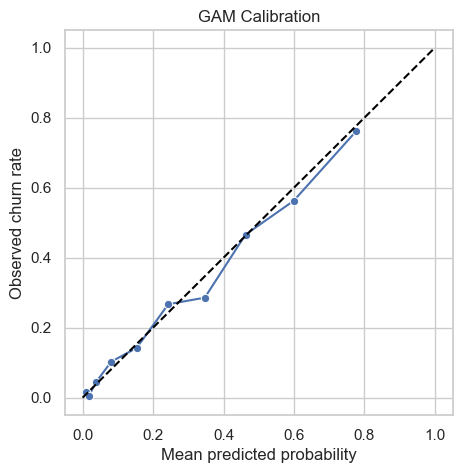

In [106]:
gam_prob_test = gam_results.predict(exog=X_test_gam_linear, exog_smooth=X_test_num_scaled)
gam_class_test = (gam_prob_test >= 0.5).astype(int)

gam_calibration = calibration_table(y_test, gam_prob_test)
display(gam_calibration)

fig, ax = plt.subplots(figsize=(5, 5))
sns.lineplot(data=gam_calibration, x='mean_predicted_probability', y='observed_churn_rate', marker='o', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='black')
ax.set_title('GAM Calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed churn rate')
plt.show()


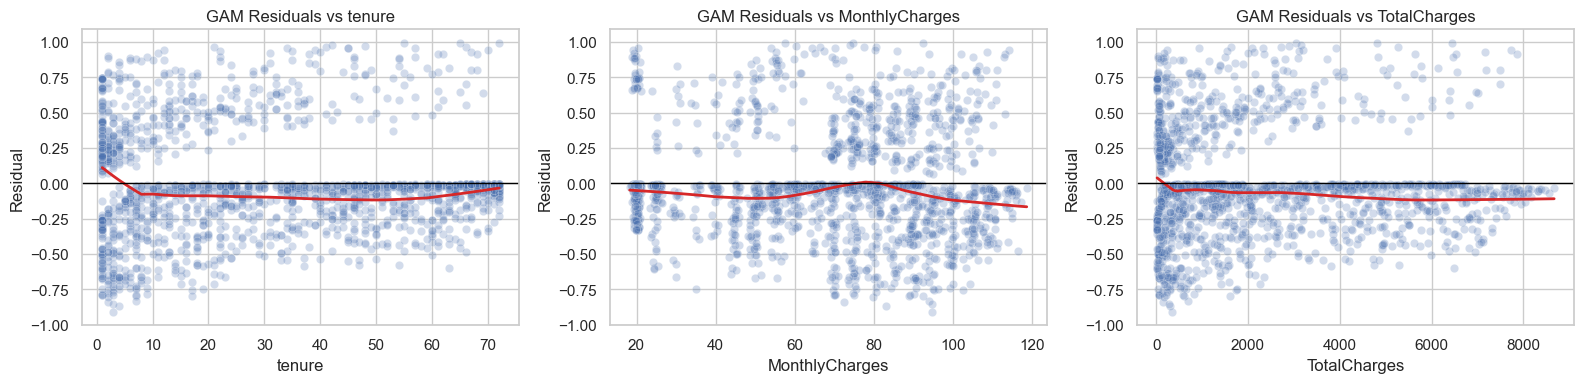

In [107]:
gam_residuals = y_test - gam_prob_test
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    sns.scatterplot(x=X_test[col], y=gam_residuals, alpha=0.25, ax=ax)
    smooth = lowess(gam_residuals, X_test[col], frac=0.35, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], color='#D62728', linewidth=2)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'GAM Residuals vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Residual')
plt.tight_layout()
plt.show()


### Performance


In [108]:
gam_performance = classification_metrics(y_test, gam_prob_test, gam_class_test)
gam_performance.to_frame('GAM')


,GAM
ROC_AUC,0.842181
Brier,0.137321
Accuracy,0.796928
Precision,0.642487
Recall,0.531049
F1,0.581477


              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1291
       Churn       0.64      0.53      0.58       467

    accuracy                           0.80      1758
   macro avg       0.74      0.71      0.72      1758
weighted avg       0.79      0.80      0.79      1758



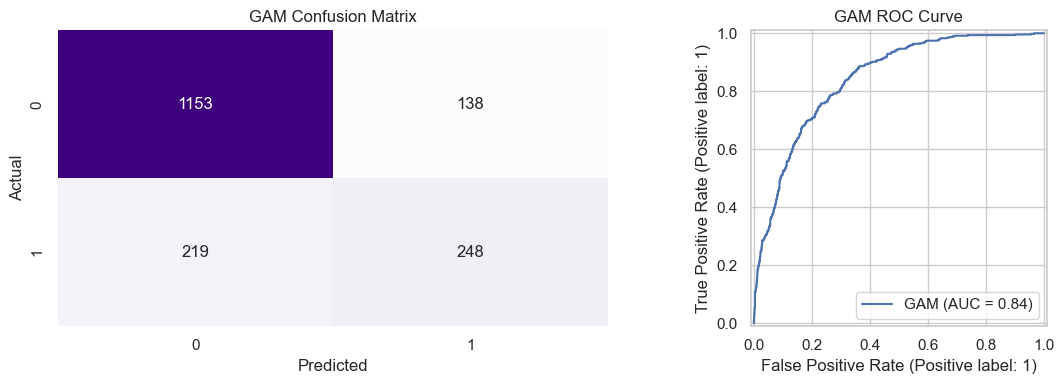

In [109]:
print(classification_report(y_test, gam_class_test, target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, gam_class_test), annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[0])
axes[0].set_title('GAM Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, gam_prob_test, ax=axes[1], name='GAM')
axes[1].set_title('GAM ROC Curve')
plt.tight_layout()
plt.show()


### Partial dependence / interpretation

The partial dependence plots show how each numeric feature changes predicted churn risk while holding other model terms constant. The y-axis is predicted churn probability, so both the direction and the curve shape are useful for interpretation.


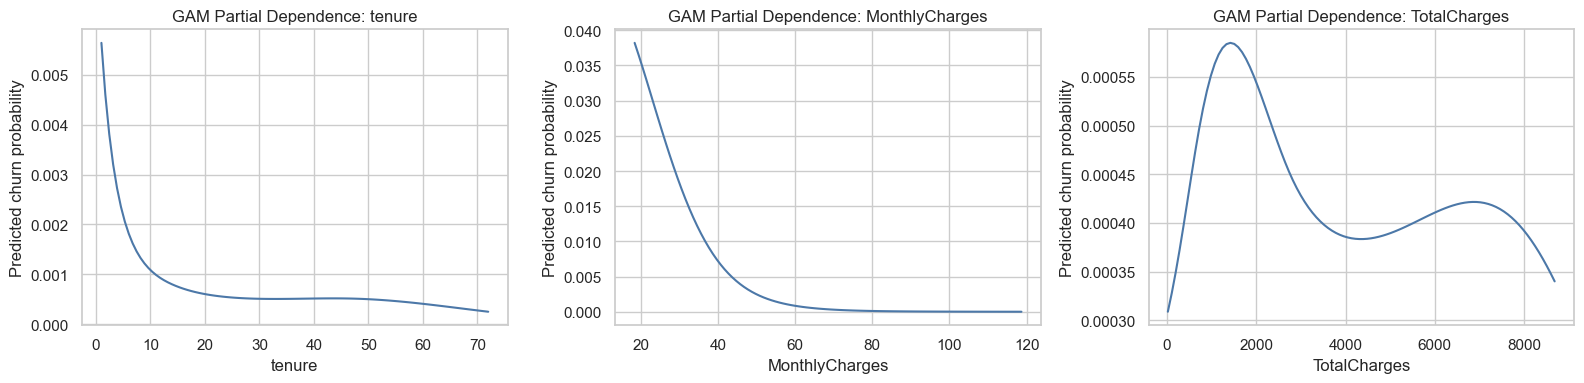

In [110]:
def plot_gam_smooth(feature, feature_index, grid_points=100):
    x_original = np.linspace(X_train[feature].min(), X_train[feature].max(), grid_points)
    x_scaled = (x_original - num_scaler_for_gam.mean_[feature_index]) / num_scaler_for_gam.scale_[feature_index]

    # Hold other smooth variables at their training mean after scaling, which is approximately 0.
    smooth_grid = pd.DataFrame(np.zeros((grid_points, len(numeric_features))), columns=numeric_features)
    smooth_grid[feature] = x_scaled

    linear_base = pd.DataFrame(
        np.zeros((grid_points, X_train_gam_linear.shape[1])),
        columns=X_train_gam_linear.columns,
    )
    linear_base['const'] = 1

    predicted_probability = gam_results.predict(exog=linear_base, exog_smooth=smooth_grid)

    return pd.DataFrame({feature: x_original, 'predicted_churn_probability': predicted_probability})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (ax, feature) in enumerate(zip(axes, numeric_features)):
    pdp = plot_gam_smooth(feature, i)
    sns.lineplot(data=pdp, x=feature, y='predicted_churn_probability', ax=ax, color='#4C78A8')
    ax.set_title(f'GAM Partial Dependence: {feature}')
    ax.set_ylabel('Predicted churn probability')
plt.tight_layout()
plt.show()


In [111]:
gam_linear_params = gam_results.params[:X_train_gam_linear.shape[1]]
gam_cat_effects = pd.DataFrame({
    'feature': X_train_gam_linear.columns,
    'coefficient_log_odds': gam_linear_params,
})
gam_cat_effects = gam_cat_effects[gam_cat_effects['feature'] != 'const'].copy()
gam_cat_effects['odds_ratio'] = np.exp(gam_cat_effects['coefficient_log_odds'])

display(gam_cat_effects.sort_values('odds_ratio', ascending=False).head(10))
display(gam_cat_effects.sort_values('odds_ratio').head(10))


,feature,coefficient_log_odds,odds_ratio
PhoneService_Yes,PhoneService_Yes,3.508054,33.383240
InternetService_Fiber optic,InternetService_Fiber optic,3.384443,29.501558
MultipleLines_No phone service,MultipleLines_No phone service,2.045688,7.734479
StreamingTV_Yes,StreamingTV_Yes,1.253170,3.501425
StreamingMovies_Yes,StreamingMovies_Yes,1.209609,3.352175
MultipleLines_Yes,MultipleLines_Yes,0.870590,2.388319
DeviceProtection_Yes,DeviceProtection_Yes,0.500267,1.649162
PaperlessBilling_Yes,PaperlessBilling_Yes,0.329488,1.390257
PaymentMethod_Electronic check,PaymentMethod_Electronic check,0.295142,1.343318
OnlineBackup_Yes,OnlineBackup_Yes,0.270893,1.311134


,feature,coefficient_log_odds,odds_ratio
Contract_Two year,Contract_Two year,-1.623039,0.197298
Contract_One year,Contract_One year,-0.731151,0.481355
DeviceProtection_No internet service,DeviceProtection_No internet service,-0.454573,0.634719
OnlineSecurity_No internet service,OnlineSecurity_No internet service,-0.454573,0.634719
TechSupport_No internet service,TechSupport_No internet service,-0.454573,0.634719
StreamingMovies_No internet service,StreamingMovies_No internet service,-0.454573,0.634719
InternetService_No,InternetService_No,-0.454573,0.634719
StreamingTV_No internet service,StreamingTV_No internet service,-0.454573,0.634719
OnlineBackup_No internet service,OnlineBackup_No internet service,-0.454573,0.634719
Dependents_Yes,Dependents_Yes,-0.203673,0.815729


In [112]:
gam_interpretation = """
The GAM is still interpretable, but its interpretation is visual as well as coefficient-based.
For numeric variables, the shape of the curve matters. For categorical variables, the linear coefficients can still be read as log-odds effects.
If the GAM improves calibration or ROC AUC over logistic regression, it suggests that non-linear churn patterns are useful.
"""
print(gam_interpretation)



The GAM is still interpretable, but its interpretation is visual as well as coefficient-based.
For numeric variables, the shape of the curve matters. For categorical variables, the linear coefficients can still be read as log-odds effects.
If the GAM improves calibration or ROC AUC over logistic regression, it suggests that non-linear churn patterns are useful.



## Model Comparison

This section compares predictive performance and interpretability. The exact numbers may change slightly if the train-test split or package versions change.


In [113]:
comparison = pd.DataFrame({
    'Linear Regression': linear_performance,
    'Logistic Regression': logistic_performance,
    'GAM': gam_performance,
}).T

comparison = comparison[['ROC_AUC', 'Brier', 'Accuracy', 'Precision', 'Recall', 'F1']]
comparison


,ROC_AUC,Brier,Accuracy,Precision,Recall,F1
Linear Regression,0.832347,0.141700,0.799772,0.648579,0.537473,0.587822
Logistic Regression,0.840090,0.171195,0.733220,0.498660,0.796574,0.613355
GAM,0.842181,0.137321,0.796928,0.642487,0.531049,0.581477


In [114]:
model_comparison_notes = pd.DataFrame([
    {
        'Model': 'Linear regression',
        'Performance evidence': 'Baseline metrics from clipped predictions; useful for comparison but not ideal for probability modeling',
        'Interpretability strength': 'Coefficients are simple changes in predicted churn probability',
        'Interpretability weakness': 'Binary target violates assumptions; predicted values can fall outside valid probability range',
    },
    {
        'Model': 'Logistic regression',
        'Performance evidence': 'ROC AUC, Brier score, confusion matrix, classification report, calibration table',
        'Interpretability strength': 'Odds ratios are clear and business-friendly',
        'Interpretability weakness': 'Numeric effects must be linear on the log-odds scale unless engineered otherwise',
    },
    {
        'Model': 'GAM',
        'Performance evidence': 'ROC AUC, Brier score, confusion matrix, classification report, calibration table',
        'Interpretability strength': 'Shows non-linear numeric effects using partial dependence curves',
        'Interpretability weakness': 'More complex to explain than logistic regression and does not capture interactions by default',
    },
])

model_comparison_notes


,Model,Performance evidence,Interpretability strength,Interpretability weakness
0,Linear regression,Baseline metrics from clipped predictions; use...,Coefficients are simple changes in predicted c...,Binary target violates assumptions; predicted ...
1,Logistic regression,"ROC AUC, Brier score, confusion matrix, classi...",Odds ratios are clear and business-friendly,Numeric effects must be linear on the log-odds...
2,GAM,"ROC AUC, Brier score, confusion matrix, classi...",Shows non-linear numeric effects using partial...,More complex to explain than logistic regressi...


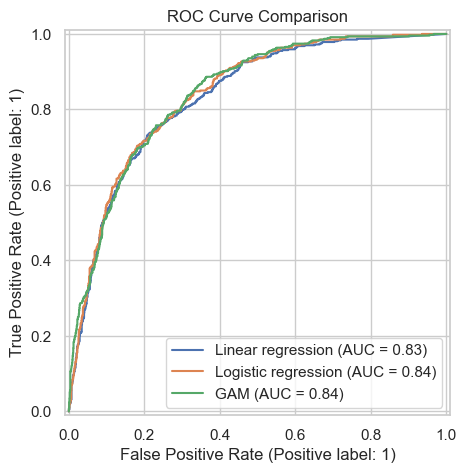

In [115]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, linear_prob_test, name='Linear regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, logistic_prob_test, name='Logistic regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, gam_prob_test, name='GAM', ax=ax)
ax.set_title('ROC Curve Comparison')
plt.show()


## Recommendation

This recommendation is based on the executed model comparison table above. In this run, the main test-set results were:

| Model | ROC AUC | Brier | Accuracy | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| Linear regression | 0.832 | 0.142 | 0.800 | 0.537 | 0.588 |
| Logistic regression | 0.840 | 0.171 | 0.733 | 0.797 | 0.613 |
| GAM | 0.842 | 0.137 | 0.797 | 0.531 | 0.581 |

Recommended model: **Logistic regression as the first business-facing churn model, with GAM used as a supporting model to study non-linear effects.**

Why this model:

- Logistic regression is appropriate for a binary churn target and gives directly interpretable odds ratios.
- It had the best recall in this run, identifying about 79.7% of churners at the default 0.5 threshold. For a retention team, missing a likely churner can be more costly than sending extra outreach.
- Its F1 score was also the strongest among the three models in this run.
- GAM had the best ROC AUC and Brier score, so it is useful if the company cares most about probability ranking or calibration. However, its partial dependence curves are harder to communicate than logistic odds ratios.
- Linear regression is useful as a simple baseline, but it is not the recommended model because churn is binary and the linear regression assumptions are clearly strained.

What the company can responsibly conclude:

- Contract type, tenure, payment method, internet service, and support/security services are associated with churn risk.
- The model can help prioritize customers for retention outreach, especially customers with high predicted churn probability.
- Longer contracts and longer tenure are associated with lower churn risk, while month-to-month contracts and electronic check payment are associated with higher churn risk.

What the company should not conclude yet:

- The model does not prove that any feature causes churn.
- The model should not be used to claim that changing one feature will automatically prevent churn.
- The analysis does not yet test fairness, customer satisfaction history, price changes, competitor offers, or whether performance holds over time.

One next analysis to run:

- Tune the classification threshold using the retention team's outreach capacity and the cost of false positives versus false negatives. If customer signup and churn dates are available, also run time-aware validation or survival analysis.


## Final Notes for Submission

This notebook is designed for Google Colab and should run from top to bottom. If Kaggle access is unavailable, place `WA_Fn-UseC_-Telco-Customer-Churn.csv` or `Telco-Customer-Churn.csv` in a local `data/` folder and rerun the notebook.
